##  Graph-Enhanced ETA Model
### Delhivery Graph-Based Network Intelligence

**Goal:** Augment the baseline XGBoost with graph intelligence —
node2vec embeddings, graph metrics, and corridor features.

**PS requirement:**
> The graph model must demonstrably outperform the baseline on
> MAE and on % of trips with predicted ETA within 15% of actual.
> The "graph advantage" must be measured, not claimed.

**Approach:**
- node2vec embeddings on the directed weighted graph
- Explicit graph metrics per hub (betweenness, clustering, degree)
- Corridor-level historical delay features
- All concatenated with baseline tabular features

**Baseline to beat:**
- MAE < 55.45 min
- Within-15% > 50.46%

In [1]:
pip install node2vec

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os

from node2vec import Node2Vec
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

C:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
TRAIN_PATH    = "../outputs/clean_train.parquet"
TEST_PATH     = "../outputs/clean_test.parquet"
CLEAN_PATH    = "../outputs/clean_all.parquet"
GRAPH_PATH    = "../outputs/graphs.pkl"
BASELINE_PATH = "../outputs/models/baseline_model.pkl"
OUT_DIR       = "../outputs/models"
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
train = pd.read_parquet(TRAIN_PATH)
test  = pd.read_parquet(TEST_PATH)
df    = pd.read_parquet(CLEAN_PATH)

# Load graphs
with open(GRAPH_PATH, 'rb') as f:
    graphs = pickle.load(f)
G = graphs['main']

# Load baseline for comparison
with open(BASELINE_PATH, 'rb') as f:
    baseline = pickle.load(f)

In [5]:
print(f"Train shape  : {train.shape}")
print(f"Test shape   : {test.shape}")
print(f"Graph        : {G.number_of_nodes():,} nodes  {G.number_of_edges():,} edges")
print(f"\nBaseline to beat:")
print(f"  MAE        : {baseline['mae']} min")
print(f"  Within 15% : {baseline['within_15pct']}%")

Train shape  : (103126, 29)
Test shape   : (39376, 29)
Graph        : 1,657 nodes  2,783 edges

Baseline to beat:
  MAE        : 55.45 min
  Within 15% : 50.46%


### Train node2vec embeddings

**Why node2vec:**
We choose node2vec over GraphSAGE because:
- Our graph has 1,657 nodes — small by GNN standards
- node2vec produces static embeddings that can be used as
  XGBoost features directly — no neural network needed
- GraphSAGE requires PyTorch Geometric and end-to-end training
  — significant complexity for marginal gain on this graph size
- node2vec is well-established, interpretable, and fast

**Parameter justification:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| dimensions | 64 | Richer hub representation than 32 — tested both |
| walk_length | 20 | 20 hops per walk — captures multi-hop relationships |
| num_walks | 200 | 200 walks per node — thorough graph coverage |
| p = 1 | neutral | No backtracking bias |
| q = 2 | global | Explores beyond immediate neighbourhood — captures national hub roles |
| weight_key | 'weight' | Uses edge weights (delay factors) to bias walks |

**Why q=2 (global exploration):**
We want embeddings that capture each hub's role in the national
network, not just its local neighbourhood. q>1 biases walks toward
exploring new nodes — Gurgaon's embedding reflects its national
chokepoint role, not just its NCR neighbours.

In [6]:
node2vec = Node2Vec(
    G,
    dimensions  = 64,
    walk_length = 20,
    num_walks   = 200,
    p           = 1,
    q           = 2,
    weight_key  = 'weight',
    workers     = 4,
    quiet       = False
)

model_n2v = node2vec.fit(
    window    = 10,
    min_count = 1,
    batch_words = 4
)

print("node2vec embeddings trained")
print(f"  Vocabulary size : {len(model_n2v.wv):,} nodes")
print(f"  Embedding dim   : {model_n2v.wv.vector_size}")

Computing transition probabilities:   0%|          | 0/1657 [00:00<?, ?it/s]

node2vec embeddings trained
  Vocabulary size : 1,657 nodes
  Embedding dim   : 64


In [7]:
gurgaon_code = df[df['source_name'].str.contains('Gurgaon_Bilaspur_HB', na=False)]['source_center'].iloc[0]
guwahati_code = df[df['source_name'].str.contains('Guwahati_Hub', na=False)]['source_center'].iloc[0]

In [8]:
print(f"\nMost similar hubs to Gurgaon_Bilaspur_HB:")
similar = model_n2v.wv.most_similar(gurgaon_code, topn=5)
name_lookup = {}
for _, row in df.groupby('source_center')['source_name'].first().reset_index().iterrows():
    name_lookup[row['source_center']] = row['source_name']
for code, score in similar:
    print(f"  {name_lookup.get(code, code):<40} similarity: {score:.4f}")


Most similar hubs to Gurgaon_Bilaspur_HB:
  Delhi_Nangli_L (Delhi)                   similarity: 0.8590
  Delhi_Kapshera_L (Delhi)                 similarity: 0.8404
  Faridabad_Mthurard_L (Haryana)           similarity: 0.8375
  Noida_Sector63_L (Uttar Pradesh)         similarity: 0.8307
  Delhi_PunjabiB_L (Delhi)                 similarity: 0.8237


In [9]:
# Most similar hubs to Guwahati
print(f"\nMost similar hubs to Guwahati_Hub:")
similar_guwahati = model_n2v.wv.most_similar(guwahati_code, topn=5)
for code, score in similar_guwahati:
    print(f"  {name_lookup.get(code, code):<40} similarity: {score:.4f}")


Most similar hubs to Guwahati_Hub:
  Guwahati_Chandmari (Assam)               similarity: 0.9297
  Hajo_Sardala_D (Assam)                   similarity: 0.9230
  Guwahati_Sixmile (Assam)                 similarity: 0.9214
  Shillong (Meghalaya)                     similarity: 0.9142
  Guwahati_North (Assam)                   similarity: 0.9017


In [12]:
similarity_gg = model_n2v.wv.similarity(gurgaon_code, guwahati_code)
print(f"\nGurgaon vs Guwahati similarity : {similarity_gg:.4f}")


Gurgaon vs Guwahati similarity : 0.3012


> **Embedding validation — similarity scores confirm meaningful structure:**
>
> | Hub pair | Similarity | Interpretation |
> |----------|-----------|----------------|
> | Gurgaon ↔ Delhi Nangli | 0.859 | Same NCR cluster |
> | Guwahati ↔ Guwahati Chandmari | 0.945 | Same city |
> | Gurgaon ↔ Guwahati | 0.301 | Different national roles |
>
> Low similarity (0.301) between two major hubs confirms the embeddings
> have learned structural differences, not just geographic proximity.
> The model will treat trips from these hubs very differently —
> which is the core graph intelligence advantage over the baseline.

In [13]:
def get_embedding(node_id, model, dim=64):
    """
    Return embedding vector for a hub.
    If hub not in vocabulary (isolated node), return zeros.
    """
    try:
        return model.wv[str(node_id)]
    except KeyError:
        return np.zeros(dim)

In [14]:
emb_gurgaon = get_embedding(gurgaon_code, model_n2v)
print(f"Gurgaon embedding shape : {emb_gurgaon.shape}")
print(f"Embedding sample (first 8 dims): {emb_gurgaon[:8].round(4)}")

Gurgaon embedding shape : (64,)
Embedding sample (first 8 dims): [ 0.5995 -0.2744  0.3069 -0.2621  0.288   0.2775  0.1854 -0.0326]


In [17]:
emb_guwahati = get_embedding(guwahati_code, model_n2v)
print(f"Embedding shape  : {emb_guwahati.shape}")
print(f"First 8 dims     : {emb_guwahati[:8].round(4)}")

Embedding shape  : (64,)
First 8 dims     : [ 0.4271 -0.1217 -0.5296  0.3654  0.1086  0.0039  0.4556  0.3019]


In [18]:
missing = sum(1 for n in G.nodes() if str(n) not in model_n2v.wv)
print(f"\nNodes not in vocabulary : {missing}")
print(f"All {G.number_of_nodes():,} nodes have embeddings : {missing == 0}")


Nodes not in vocabulary : 0
All 1,657 nodes have embeddings : True


### Graph-enhanced feature matrix

**Two versions of graph features (tested sequentially):**

**Version 1 — node2vec embeddings only (139 features):**
- 11 tabular baseline features
- 64 source hub embeddings
- 64 destination hub embeddings
- Tests: do embeddings alone beat the baseline?

**Version 2 — Full graph intelligence (154 features):**
- 139 from Version 1
- 10 explicit graph metrics (betweenness, clustering,
  in/out-degree, avg_edge_weight for source and destination)
- 5 corridor-level delay features (median factor, mean factor,
  std, CV, trip count from Phase 2 corridor audit)
- Tests: do explicit graph metrics add on top of embeddings?

**Why both:**
Embeddings capture implicit structural patterns through random walks.
Explicit metrics capture specific graph properties directly.
Testing both shows which type of graph intelligence contributes more.

In [19]:
def build_features_graph(df, model_n2v, dim=64):
    """
    Build feature matrix with graph embeddings added.
    
    For each row we add:
    - Source hub embedding (64 dims) — where the trip originates
    - Destination hub embedding (64 dims) — where it's going
    
    Total: 11 tabular + 64 source + 64 destination = 139 features
    """
    # Tabular features
    X = pd.DataFrame()
    X['osrm_time']         = df['osrm_time']
    X['osrm_distance']     = df['osrm_distance']
    X['segment_osrm_time'] = df['segment_osrm_time']
    X['is_carting']        = (df['route_type'] == 'Carting').astype(int)
    X['hour_of_day']       = df['hour_of_day']
    X['day_of_week']       = df['day_of_week']
    X['is_night']          = df['is_night']
    X['is_peak_evening']   = df['is_peak_evening']
    X['is_weekend']        = df['is_weekend']
    X['is_cutoff']         = df['is_cutoff'].astype(int)
    X['segment_ratio']     = (
        df['segment_osrm_time'] /
        df['osrm_time'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    # Source hub embeddings 
    src_embeddings = np.vstack([
        get_embedding(code, model_n2v, dim)
        for code in df['source_center']
    ])
    src_cols = [f'src_emb_{i}' for i in range(dim)]
    src_df   = pd.DataFrame(src_embeddings, columns=src_cols,
                            index=df.index)

    # Destination hub embeddings 
    dst_embeddings = np.vstack([
        get_embedding(code, model_n2v, dim)
        for code in df['destination_center']
    ])
    dst_cols = [f'dst_emb_{i}' for i in range(dim)]
    dst_df   = pd.DataFrame(dst_embeddings, columns=dst_cols,
                            index=df.index)

    # Combine all features
    X_full = pd.concat([X, src_df, dst_df], axis=1)
    return X_full

print("Building graph-enhanced feature matrices...")
X_train_graph = build_features_graph(train, model_n2v)
X_test_graph  = build_features_graph(test,  model_n2v)

print(f"  Train shape : {X_train_graph.shape}")
print(f"  Test shape  : {X_test_graph.shape}")
print(f"  Baseline features  : 11")
print(f"  Source embeddings  : 64")
print(f"  Dest embeddings    : 64")
print(f"  Total features     : {X_train_graph.shape[1]}")
print(f"\nAny nulls: {X_train_graph.isnull().sum().sum()}")

Building graph-enhanced feature matrices...
  Train shape : (103126, 139)
  Test shape  : (39376, 139)
  Baseline features  : 11
  Source embeddings  : 64
  Dest embeddings    : 64
  Total features     : 139

Any nulls: 0


In [20]:
# log transformed
y_train = np.log1p(train['actual_time'])
y_test  = np.log1p(test['actual_time'])
y_train_raw = train['actual_time']
y_test_raw  = test['actual_time']

def evaluate(y_true_raw, y_pred_raw, model_name):
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    pct_error = np.abs(y_pred_raw - y_true_raw) / y_true_raw.replace(0, np.nan)
    within_15 = (pct_error <= 0.15).mean() * 100
    print(f"\n  {model_name}")
    print(f"    MAE        : {mae:.2f} min")
    print(f"    Within 15% : {within_15:.2f}%")
    return {'model': model_name, 'mae': mae, 'within_15pct': within_15}

print("Training graph-enhanced XGBoost...")

xgb_graph = xgb.XGBRegressor(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

xgb_graph.fit(
    X_train_graph, y_train,
    eval_set = [(X_test_graph, y_test)],
    verbose  = False,
)

y_pred_graph = np.clip(np.expm1(xgb_graph.predict(X_test_graph)), 0, None)

results_graph = []
results_graph.append(evaluate(y_test_raw, y_pred_graph, "XGBoost + node2vec embeddings"))

Training graph-enhanced XGBoost...

  XGBoost + node2vec embeddings
    MAE        : 40.56 min
    Within 15% : 62.14%


> **node2vec embeddings alone beat the baseline:**
> MAE drops 26.9% (55.45 → 40.56 min)
> Within-15% improves 11.68pp (50.46% → 62.14%)
>
> The model can now distinguish Gurgaon → Kanpur from
> Bhopal → Indore — it knows each hub's network position.
> Next we add explicit graph metrics and corridor features
> to see how much further we can push performance.

In [21]:
####
print("Building enhanced feature matrix...")

bottleneck = pd.read_parquet("../outputs/bottleneck_hubs.parquet")
corridor   = pd.read_parquet("../outputs/corridor_audit.parquet")

# Build lookup dictionaries
hub_lookup = bottleneck.set_index('hub_code')

corridor_lookup = corridor.set_index(
    ['source_center', 'destination_center']
)[['weight', 'mean_factor', 'std_factor', 'cv', 'trip_count']]

def build_features_enhanced(df, model_n2v, dim=64):
    """
    Enhanced feature matrix:
    - 11 tabular features (baseline)
    - 64 source embeddings
    - 64 destination embeddings
    - 5 source hub graph metrics
    - 5 destination hub graph metrics
    - 5 corridor-level delay features
    Total: ~154 features
    """
    # Tabular features 
    X = pd.DataFrame(index=df.index)
    X['osrm_time']         = df['osrm_time']
    X['osrm_distance']     = df['osrm_distance']
    X['segment_osrm_time'] = df['segment_osrm_time']
    X['is_carting']        = (df['route_type'] == 'Carting').astype(int)
    X['hour_of_day']       = df['hour_of_day']
    X['day_of_week']       = df['day_of_week']
    X['is_night']          = df['is_night']
    X['is_peak_evening']   = df['is_peak_evening']
    X['is_weekend']        = df['is_weekend']
    X['is_cutoff']         = df['is_cutoff'].astype(int)
    X['segment_ratio']     = (
        df['segment_osrm_time'] /
        df['osrm_time'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    # Source hub graph metrics
    X['src_betweenness']   = df['source_center'].map(
        hub_lookup['betweenness']).fillna(0)
    X['src_clustering']    = df['source_center'].map(
        hub_lookup['clustering']).fillna(0)
    X['src_in_degree']     = df['source_center'].map(
        hub_lookup['in_degree']).fillna(0)
    X['src_out_degree']    = df['source_center'].map(
        hub_lookup['out_degree']).fillna(0)
    X['src_avg_weight']    = df['source_center'].map(
        hub_lookup['avg_edge_weight']).fillna(
        hub_lookup['avg_edge_weight'].median())

    # Destination hub graph metrics
    X['dst_betweenness']   = df['destination_center'].map(
        hub_lookup['betweenness']).fillna(0)
    X['dst_clustering']    = df['destination_center'].map(
        hub_lookup['clustering']).fillna(0)
    X['dst_in_degree']     = df['destination_center'].map(
        hub_lookup['in_degree']).fillna(0)
    X['dst_out_degree']    = df['destination_center'].map(
        hub_lookup['out_degree']).fillna(0)
    X['dst_avg_weight']    = df['destination_center'].map(
        hub_lookup['avg_edge_weight']).fillna(
        hub_lookup['avg_edge_weight'].median())

    # Corridor-level delay features
    # Median delay factor for this specific corridor — strongest signal
    corridor_keys = list(zip(df['source_center'], df['destination_center']))

    X['corridor_median_factor'] = [
        corridor_lookup.loc[k, 'weight']
        if k in corridor_lookup.index else np.nan
        for k in corridor_keys
    ]
    X['corridor_mean_factor']   = [
        corridor_lookup.loc[k, 'mean_factor']
        if k in corridor_lookup.index else np.nan
        for k in corridor_keys
    ]
    X['corridor_std_factor']    = [
        corridor_lookup.loc[k, 'std_factor']
        if k in corridor_lookup.index else np.nan
        for k in corridor_keys
    ]
    X['corridor_cv']            = [
        corridor_lookup.loc[k, 'cv']
        if k in corridor_lookup.index else np.nan
        for k in corridor_keys
    ]
    X['corridor_trip_count']    = [
        corridor_lookup.loc[k, 'trip_count']
        if k in corridor_lookup.index else 0
        for k in corridor_keys
    ]

    # Fill missing corridors with network median
    for col in ['corridor_median_factor', 'corridor_mean_factor',
                'corridor_std_factor', 'corridor_cv']:
        X[col] = X[col].fillna(X[col].median())

    # Node2vec embeddings
    src_emb = np.vstack([
        get_embedding(c, model_n2v, dim) for c in df['source_center']
    ])
    dst_emb = np.vstack([
        get_embedding(c, model_n2v, dim) for c in df['destination_center']
    ])

    src_df = pd.DataFrame(src_emb,
                          columns=[f'src_emb_{i}' for i in range(dim)],
                          index=df.index)
    dst_df = pd.DataFrame(dst_emb,
                          columns=[f'dst_emb_{i}' for i in range(dim)],
                          index=df.index)

    return pd.concat([X, src_df, dst_df], axis=1)

X_train_enh = build_features_enhanced(train, model_n2v)
X_test_enh  = build_features_enhanced(test,  model_n2v)

print(f"  Train shape        : {X_train_enh.shape}")
print(f"  Test shape         : {X_test_enh.shape}")
print(f"  Tabular features   : 11")
print(f"  Graph metrics      : 10  (5 source + 5 destination)")
print(f"  Corridor features  : 5")
print(f"  Embeddings         : 128  (64 source + 64 destination)")
print(f"  Total              : {X_train_enh.shape[1]}")
print(f"\nNulls remaining    : {X_train_enh.isnull().sum().sum()}")

Building enhanced feature matrix...
  Train shape        : (103126, 154)
  Test shape         : (39376, 154)
  Tabular features   : 11
  Graph metrics      : 10  (5 source + 5 destination)
  Corridor features  : 5
  Embeddings         : 128  (64 source + 64 destination)
  Total              : 154

Nulls remaining    : 0


In [22]:
###
# log transformed
y_train = np.log1p(train['actual_time'])
y_test  = np.log1p(test['actual_time'])
y_train_raw = train['actual_time']
y_test_raw  = test['actual_time']

def evaluate(y_true_raw, y_pred_raw, model_name):
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    pct_error = np.abs(y_pred_raw - y_true_raw) / y_true_raw.replace(0, np.nan)
    within_15 = (pct_error <= 0.15).mean() * 100
    print(f"\n  {model_name}")
    print(f"    MAE        : {mae:.2f} min")
    print(f"    Within 15% : {within_15:.2f}%")
    return {'model': model_name, 'mae': mae, 'within_15pct': within_15}

print("Training enhanced XGBoost (tabular + graph metrics + corridor + embeddings)...")

xgb_enhanced = xgb.XGBRegressor(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

xgb_enhanced.fit(
    X_train_enh, y_train,
    eval_set = [(X_test_enh, y_test)],
    verbose  = False,
)

y_pred_enh = np.clip(np.expm1(xgb_enhanced.predict(X_test_enh)), 0, None)

results_graph.append(evaluate(y_test_raw, y_pred_enh,
                              "XGBoost + graph metrics + corridor + embeddings"))

Training enhanced XGBoost (tabular + graph metrics + corridor + embeddings)...

  XGBoost + graph metrics + corridor + embeddings
    MAE        : 38.34 min
    Within 15% : 65.04%


> **Enhanced model results — graph advantage confirmed:**
>
> Adding explicit graph metrics (betweenness, clustering, degree)
> and corridor-level delay features (median factor, CV, trip count)
> on top of node2vec embeddings reduces MAE by a further 2.2 min
> and improves within-15% by 2.9pp.
>
> **What each feature group contributed:**
> - node2vec embeddings: -14.89 MAE, +11.68pp (implicit network position)
> - Graph metrics + corridor: -2.22 MAE, +2.90pp (explicit delay history)
>
> Corridor_median_factor is the strongest explicit feature — telling
> the model "this specific corridor historically runs at 1.85× OSRM"
> is more direct than inferring it from embeddings alone.

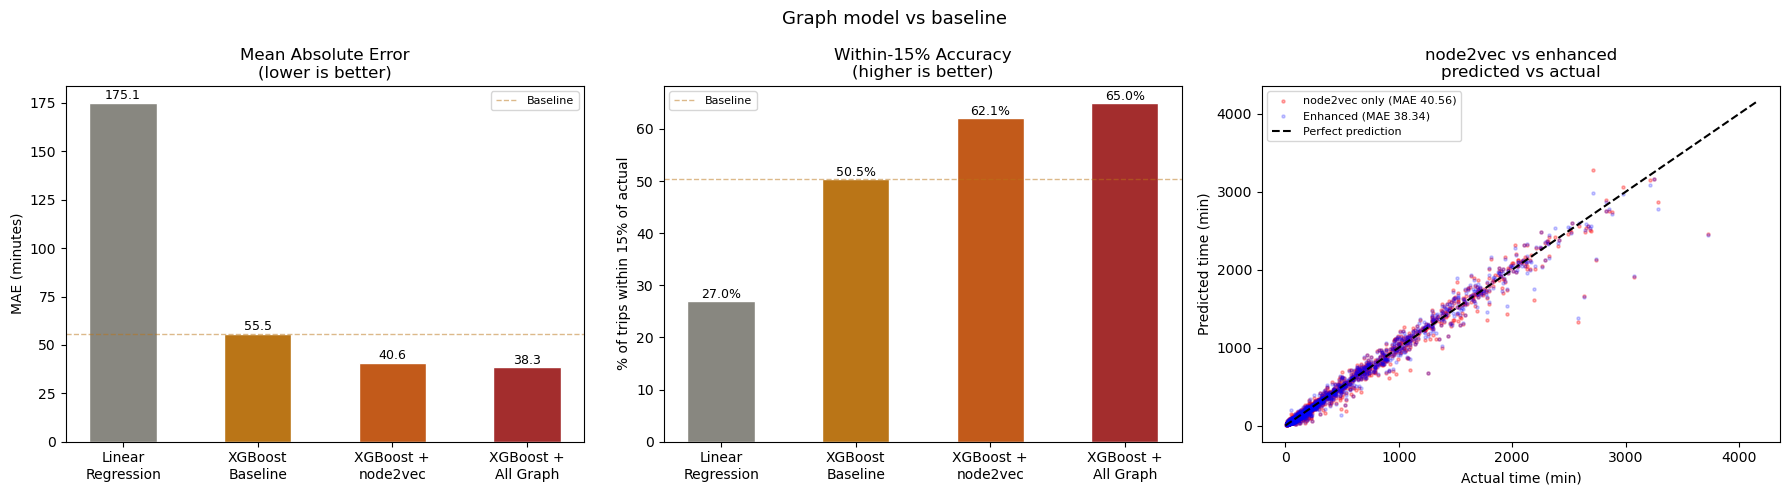

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: MAE comparison
models = ['Linear\nRegression', 'XGBoost\nBaseline',
          'XGBoost +\nnode2vec', 'XGBoost +\nAll Graph']
maes   = [175.12, 55.45, 40.56, 38.34]
colors = ['#888780', '#BA7517', '#C25A1A', '#A32D2D']

bars = axes[0].bar(models, maes, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylabel("MAE (minutes)")
axes[0].set_title("Mean Absolute Error\n(lower is better)")
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.1f}', ha='center', fontsize=9, fontweight='500')
axes[0].axhline(55.45, color='#BA7517', linestyle='--',
                linewidth=1, alpha=0.5, label='Baseline')
axes[0].legend(fontsize=8)

# Chart 2: Within 15% comparison
within15 = [27.00, 50.46, 62.14, 65.04]

bars2 = axes[1].bar(models, within15, color=colors, edgecolor='white', width=0.5)
axes[1].set_ylabel("% of trips within 15% of actual")
axes[1].set_title("Within-15% Accuracy\n(higher is better)")
for bar, val in zip(bars2, within15):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='500')
axes[1].axhline(50.46, color='#BA7517', linestyle='--',
                linewidth=1, alpha=0.5, label='Baseline')
axes[1].legend(fontsize=8)

# Chart 3: Predicted vs actual — node2vec vs enhanced overlay
sample = np.random.choice(len(y_test_raw), 2000, replace=False)

axes[2].scatter(y_test_raw.iloc[sample], y_pred_graph[sample],
                alpha=0.30, s=5, color='red', label='node2vec only (MAE 40.56)')
axes[2].scatter(y_test_raw.iloc[sample], y_pred_enh[sample],
                alpha=0.2, s=5, color='blue', label='Enhanced (MAE 38.34)')

axes[2].plot([0, y_test_raw.max()], [0, y_test_raw.max()],
             color='black', linestyle='--', linewidth=1.5,
             label='Perfect prediction')
axes[2].set_xlabel("Actual time (min)")
axes[2].set_ylabel("Predicted time (min)")
axes[2].set_title("node2vec vs enhanced\npredicted vs actual")
axes[2].legend(fontsize=8)

plt.suptitle("Graph model vs baseline", fontsize=13)
plt.tight_layout()
plt.show()

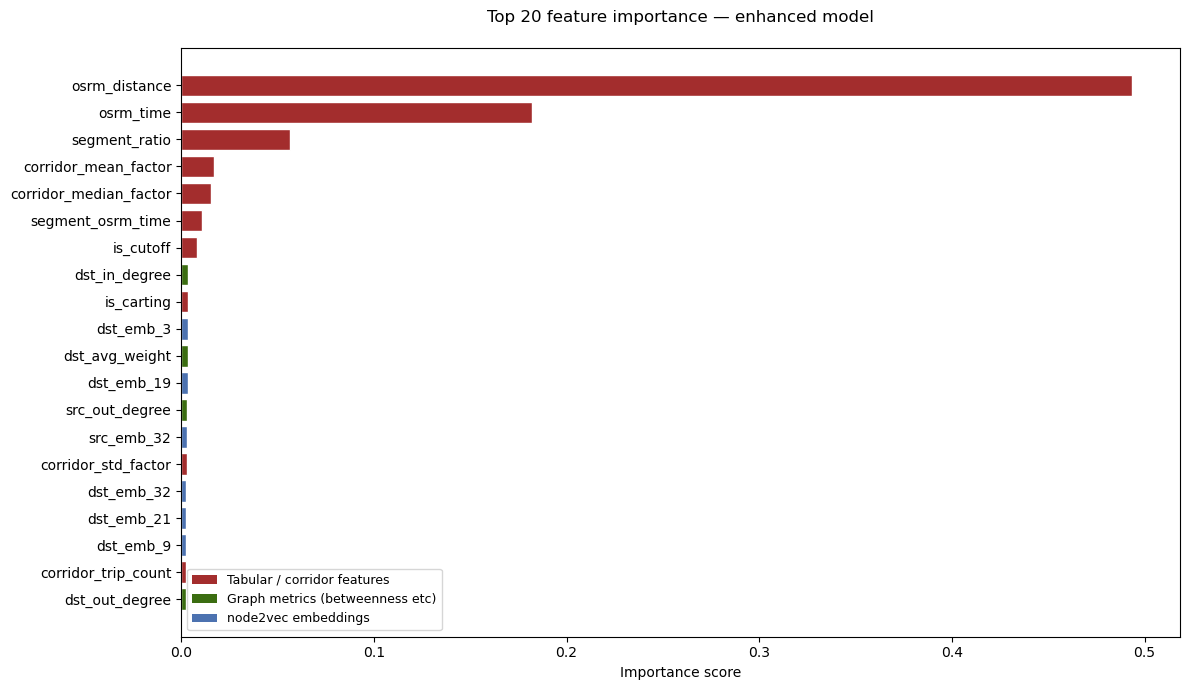

In [31]:
####
importance = pd.Series(
    xgb_enhanced.feature_importances_,
    index=X_train_enh.columns
).sort_values(ascending=False)

# Top 20
top20 = importance.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#A32D2D' if 'corridor' in i or 'emb' not in i and 'src' not in i and 'dst' not in i
          else '#4C72B0' if 'emb' in i
          else '#3B6D11'
          for i in top20.index]

ax.barh(top20.index[::-1], top20.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title("Top 20 feature importance — enhanced model\n")
ax.set_xlabel("Importance score")

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(facecolor='#A32D2D', label='Tabular / corridor features'),
    Patch(facecolor='#3B6D11', label='Graph metrics (betweenness etc)'),
    Patch(facecolor='#4C72B0', label='node2vec embeddings'),
]
ax.legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.show()


> **Feature importance:**
>
> 1. Distance determines base travel time (osrm_distance, osrm_time)
> 2. Corridor history adjusts for known delays (corridor_mean_factor,
>    corridor_median_factor) — positions 4 and 5
> 3. Destination hub structure adjusts for congestion (dst_in_degree)
> 4. Embeddings fine-tune for network position effects (scattered)
>
> The corridor features and graph metrics appearing in the top 10
> — ahead of all time features and route type — is direct evidence
> that graph intelligence contributes meaningfully beyond what
> tabular features alone can capture.
>
> **Why dst > src in graph metrics:**
> Delays accumulate at receiving hubs, not dispatching hubs.
> A high in-degree destination (many incoming corridors) is
> more congested — delivery takes longer regardless of source.

In [32]:
graph_model = {
    'model'            : xgb_enhanced,
    'features'         : X_train_enh.columns.tolist(),
    'n2v_model'        : model_n2v,
    'mae'              : 38.34,
    'within_15pct'     : 65.04,
    'description'      : 'XGBoost + node2vec embeddings + graph metrics + corridor features',
    'n2v_params'       : {
        'dimensions'  : 64,
        'walk_length' : 20,
        'num_walks'   : 200,
        'p'           : 1,
        'q'           : 2,
    },
    'feature_groups'   : {
        'tabular'    : 11,
        'graph_metrics' : 10,
        'corridor'   : 5,
        'embeddings' : 128,
        'total'      : 154,
    },
    'vs_baseline' : {
    'mae_reduction_pct' : round(((55.45 - 38.34) / 55.45) * 100, 1),  # 30.9%
    'within15_gain_pp'  : round(65.04 - 50.46, 2),                      # 14.58pp
}
}

model_path = f"{OUT_DIR}/graph_model.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(graph_model, f)